In [11]:

library(data.table)
library(igraph)
library(ggplot2)

# Helper function to plot degree distribution
plot_degree_dist <- function(g, filename, title_text = "Degree") {
  deg <- degree(g)
  df_plot <- data.frame(degree = deg)
  
  p <- ggplot(df_plot, aes(x = degree)) +
    geom_histogram(fill = "steelblue", color = NA, alpha = 0.8, bins = 30) +
    labs(title = title_text, x = "Degree (k)", y = "Count") +
    theme_classic(base_size = 18) +
    theme(
      text = element_text(face = "bold", size = 30),
      plot.title = element_text(face = "bold", hjust = 0.5, size = 30, margin = margin(b = 15)),
      axis.title = element_text(face = "bold", size = 30),
      axis.text = element_text(face = "bold", size = 30)
    )
  show(p)
  
  ggsave(filename, plot = p, width = 9, height = 6, dpi = 300, units = "in")
}

# Helper function to plot strength distribution
plot_strength_dist <- function(g, filename, title_text = "Strength") {
  # Node strength is calculated using the edge weight attribute
  str <- strength(g, weights = E(g)$duration)
  df_plot <- data.frame(strength = str)
  
  p <- ggplot(df_plot, aes(x = strength)) +
    geom_histogram(fill = "forestgreen", color = NA, alpha = 0.8, bins = 30) +
    scale_x_log10() +
    labs(title = title_text, x = "Strength (minutes)", y = "Count") +
    theme_classic(base_size = 18) +
    theme(
      text = element_text(face = "bold", size = 30),
      plot.title = element_text(face = "bold", hjust = 0.5, size = 30, margin = margin(b = 15)),
      axis.title = element_text(face = "bold", size = 30),
      axis.text = element_text(face = "bold", size = 30)
    ) +
    annotation_logticks(sides = "b")
    show(p)
  
  ggsave(filename, plot = p, width = 9, height = 6, dpi = 300, units = "in")
}

# Function to analyze static network


# Function to analyze temporal network
analyze_temporal <- function(network_csv, output_dir = "../../data/project_39/figures", info_file = "../../data/project_39/network_info.txt") {
  df <- fread(network_csv)
  
  g <- graph_from_data_frame(df, directed = FALSE)
  
  # Match the weights for the temporal network if using daily durations
  if ("CUM_DURATION" %in% edge_attr_names(g)) {
    E(g)$weight <- E(g)$CUM_DURATION
  }
  
  num_nodes <- vcount(g)
  num_edges <- ecount(g)
  
  info_text <- sprintf("\nTemporal Network Analysis:\n  File: %s\n  Number of Nodes: %d\n  Number of Edges: %d\n", 
                       basename(network_csv), num_nodes, num_edges)
  cat(info_text)
  cat(info_text, file = info_file, append = TRUE)
  
  dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)
  plot_degree_dist(g, file.path(output_dir, "temporal_degree_distribution.png"), "Temporal Network Degree Distribution")
  plot_strength_dist(g, file.path(output_dir, "temporal_strength_distribution.png"), "Temporal Network Strength Distribution")
  plot_weight_dist(g, file.path(output_dir, "temporal_weight_distribution.png"), "Temporal Network Edge Weight Distribution")
  
  return(list(nodes = num_nodes, edges = num_edges))
}


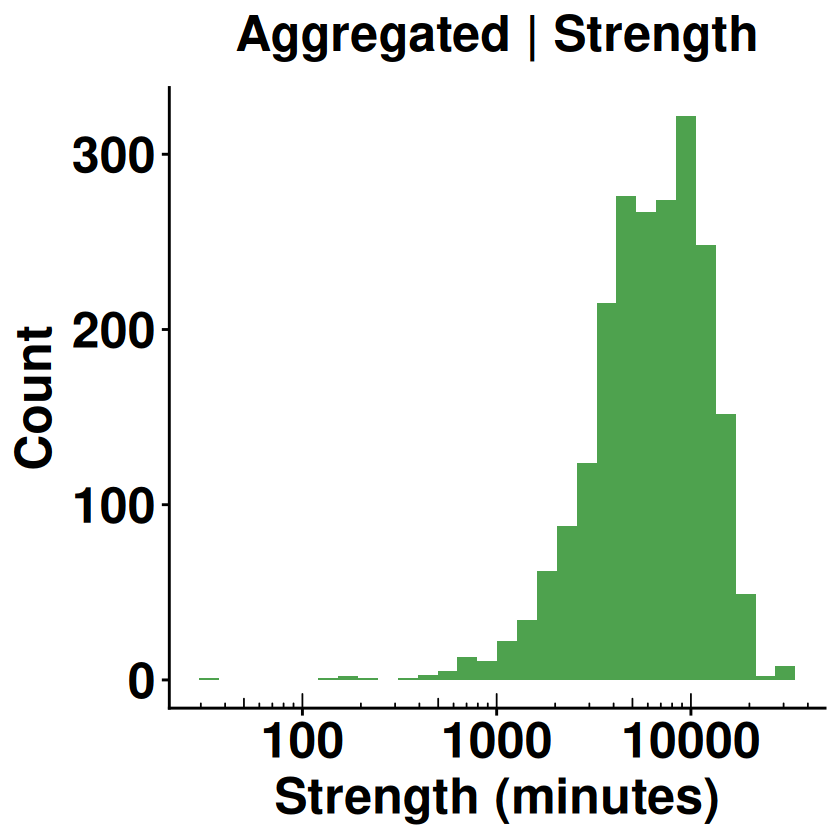

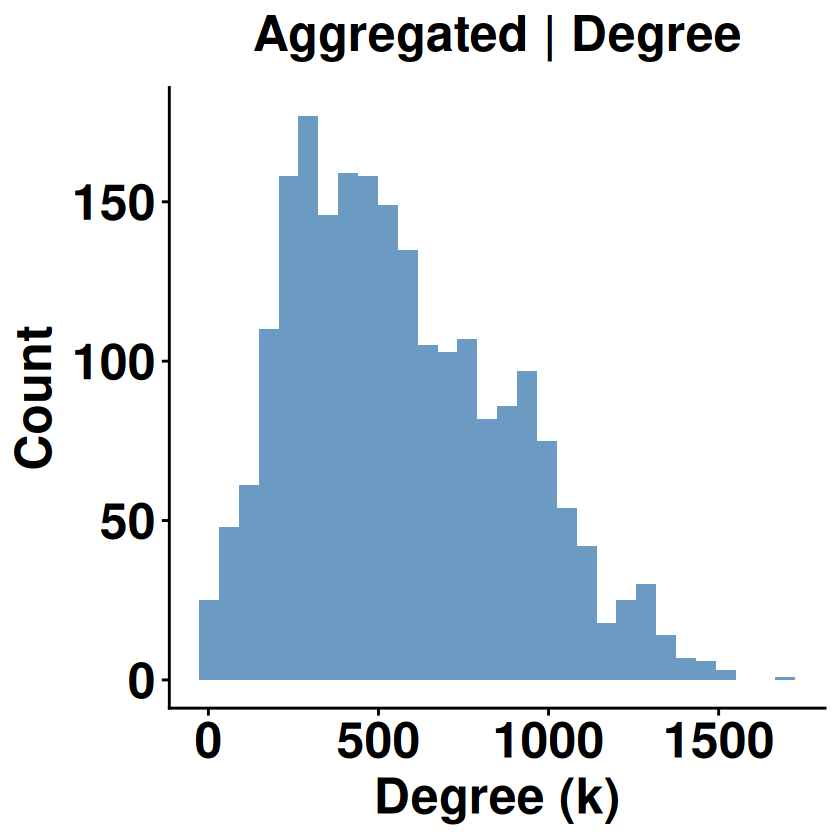

In [12]:
static_csv <- "../../data/project_39/static_network_sail_1.csv"
temporal_csv <- "../../data/project_39/temporal_network_sail_1.csv"

df <- fread(static_csv)
g <- graph_from_data_frame(df)
plot_strength_dist(g,filename="../../data/project_39/figures/aggregated_strength_dist.png", 
title_text = "Aggregated | Strength")
plot_degree_dist(g,filename="../../data/project_39/figures/aggregated_degree_dist.png", 
title_text = "Aggregated | Degree" )

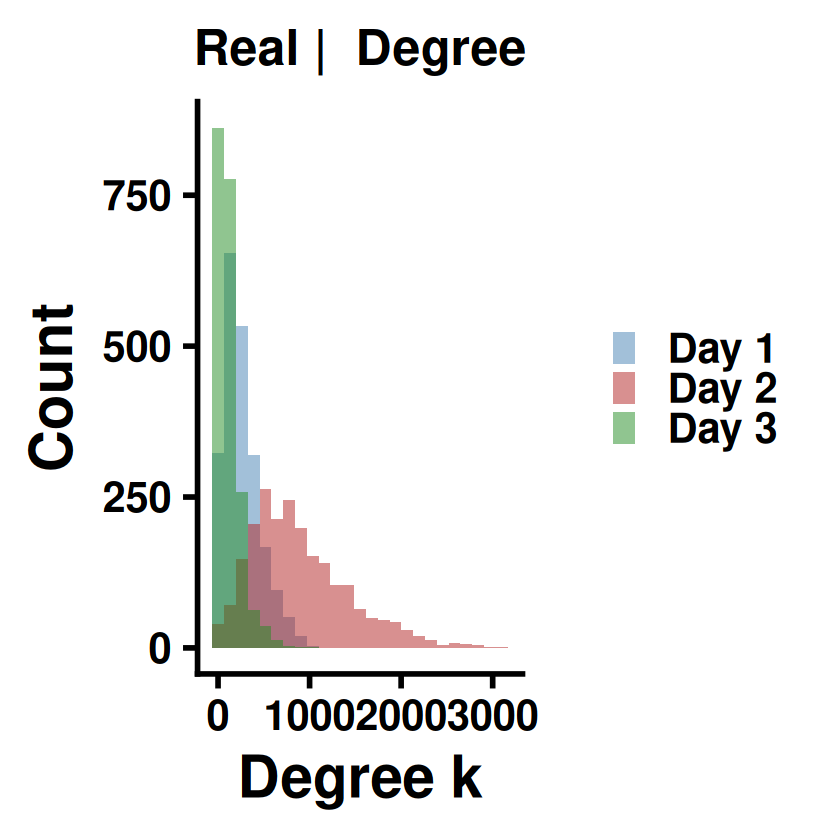

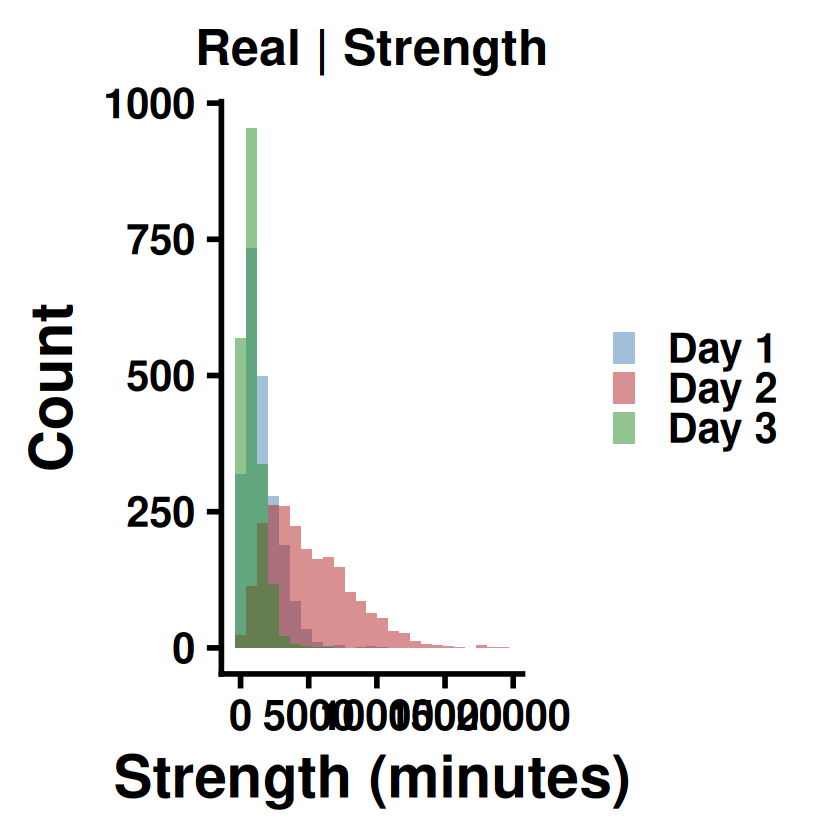

In [3]:
library(data.table)
library(igraph)
library(ggplot2)

# --- 1. Generic Overlay Plotting Function ---
# We use separate dataframes in the geom layers so we don't get errors 
# if Day 1 has 50 nodes but Day 2 has 45 nodes.
plot_superimposed_dist <- function(v1, v2, v3, day_labels, title_text, x_label, filename) {
  
  df1 <- data.frame(val = v1)
  df2 <- data.frame(val = v2)
  df3 <- data.frame(val = v3)
  
  p <- ggplot() +
    # Layer 1
    geom_histogram(data = df1, aes(x = val, fill = day_labels[1]), 
                   color = NA, alpha = 0.5, bins = 25, position = "identity") +
    # Layer 2
    geom_histogram(data = df2, aes(x = val, fill = day_labels[2]), 
                   color = NA, alpha = 0.5, bins = 25, position = "identity") +
    # Layer 3
    geom_histogram(data = df3, aes(x = val, fill = day_labels[3]), 
                   color = NA, alpha = 0.5, bins = 25, position = "identity") +
    
    scale_fill_manual(
      name = NULL, 
      values = c("steelblue", "firebrick", "forestgreen")
    ) +
    labs(title = title_text, x = x_label, y = "Count") +
    theme_classic(base_size = 35) +
    theme(
      text = element_text(face = "bold", size =30),
      plot.title = element_text(face = "bold", hjust = 0.5, size = 30, margin = margin(b = 15)),
      axis.title = element_text(face = "bold", size = 35),
      axis.text = element_text(face = "bold", size = 25),
      legend.position = "right",
      legend.title = element_text(face = "bold", size = 35),
      legend.text = element_text(face = "bold", size = 25)
    )
  
  show(p)
  ggsave(filename, plot = p, width = 9, height = 6, dpi = 300, units = "in")
}

# --- 2. Data Preparation ---

# Load your data
df <- fread(temporal_csv)

# Identify the 3 days you want to plot (replace 1, 2, 3 with your actual day values/strings)
target_days <- c(1, 2, 3) 
day_labels <- paste("Day", target_days)

# Build a separate graph for each day
g_d1 <- graph_from_data_frame(df[df$DAY_INTERACT == target_days[1], ], directed = FALSE)
g_d2 <- graph_from_data_frame(df[df$DAY_INTERACT == target_days[2], ], directed = FALSE)
g_d3 <- graph_from_data_frame(df[df$DAY_INTERACT == target_days[3], ], directed = FALSE)

# --- 3. Calculate Degree (Topology) ---
deg_d1 <- degree(g_d1)
deg_d2 <- degree(g_d2)
deg_d3 <- degree(g_d3)

# --- 4. Calculate Strength (Weighted by contact_duration) ---
# E(g)$contact_duration grabs the specific column from the original df 
str_d1 <- strength(g_d1, weights = E(g_d1)$contact_duration)
str_d2 <- strength(g_d2, weights = E(g_d2)$contact_duration)
str_d3 <- strength(g_d3, weights = E(g_d3)$contact_duration)

# --- 5. Generate and Save the Plots ---

# Plot 1: Degree Distribution
plot_superimposed_dist(
  v1 = deg_d1, 
  v2 = deg_d2, 
  v3 = deg_d3, 
  day_labels = day_labels,
  title_text = "Real |  Degree", 
  x_label = "Degree k", 
  filename = "../../data/project_39/figures/temporal_degree_dist.png"
)

# Plot 2: Strength (Duration) Distribution
plot_superimposed_dist(
  v1 = str_d1, 
  v2 = str_d2, 
  v3 = str_d3, 
  day_labels = day_labels,
  title_text = "Real | Strength", 
  x_label = "Strength (minutes)", 
  filename = "../../data/project_39/figures/temporal_strength_dist.png"
)